## 데이터 이해

In [1]:
import pandas as pd
import numpy as np


## Train dataset, Test dataset 불러오기

In [3]:
# 1. 데이터 불러오기 및 데이터 확인
df= pd.read_csv("C:\\Users\\채재헌\\OneDrive - 계명대학교\\바탕 화면\Research\\data\\raw_data\\train\\Training_Data.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\R'
<>:2: SyntaxWarning: invalid escape sequence '\R'
C:\Users\채재헌\AppData\Local\Temp\ipykernel_15592\2134028140.py:2: SyntaxWarning: invalid escape sequence '\R'
  df= pd.read_csv("C:\\Users\\채재헌\\OneDrive - 계명대학교\\바탕 화면\Research\\data\\raw_data\\train\\Training_Data.csv")


,PageNo,Speed,Length,RealPower,SetFrequency,SetDuty,SetPower,GateOnTime,WorkingTime
0,1,250,241.1,1688,1000,100,82,1154,2022-01-08 10:11:45.181
1,2,250,241.2,1713,1000,100,83,1670,2022-01-08 10:11:48.487
2,3,250,241.1,1695,1000,100,82,1153,2022-01-08 10:11:51.245
3,4,250,241.2,1717,1000,100,83,1670,2022-01-08 10:11:54.493
4,5,250,241.1,1698,1000,100,82,1154,2022-01-08 10:11:57.269


### 모든 CSV 컬럼명에 앞뒤 공백 제거

In [4]:
import pandas as pd
from pathlib import Path

data_dir = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research\data")

for csv_path in sorted(data_dir.rglob("*.csv")):
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    df.to_csv(csv_path, index=False)
    print("Updated:", csv_path.name, "->", list(df.columns))

Updated: WeldingTest_03_NG_Label.csv -> ['Unnamed: 0', 'label']
Updated: WeldingTest_04_NG_Label.csv -> ['Unnamed: 0', 'label']
Updated: WeldingTest_01_OK.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']
Updated: WeldingTest_02_OK.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']
Updated: WeldingTest_03_NG.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']
Updated: WeldingTest_04_NG.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']
Updated: Training_Data.csv -> ['PageNo', 'Speed', 'Length', 'RealPower', 'SetFrequency', 'SetDuty', 'SetPower', 'GateOnTime', 'WorkingTime']


### WorkingTime 문자열 형태의 속성을 datetime으로 변환하고 순서 정보로 정리

In [5]:
for csv_path in sorted(data_dir.rglob("*.csv")):
    df = pd.read_csv(csv_path)

    if "WorkingTime" in df.columns:
        # 문자열 타임스탬프를 datetime으로 변환
        df["WorkingTime"] = pd.to_datetime(
            df["WorkingTime"].astype(str).str.strip(),
            errors="coerce"
        )

        # 순서 정보 추가
        df["ElapsedSeconds"] = (df["WorkingTime"] - df["WorkingTime"].min()).dt.total_seconds()
        df["Sequence"] = range(1, len(df) + 1)


### NG 라벨 병합

In [ ]:
base_dir = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research")
raw_dir = base_dir / "data" / "raw_data" / "test"
label_dir = base_dir / "data" / "preprocessed" / "test"

for test_name in ["WeldingTest_03_NG", "WeldingTest_04_NG"]:
    raw_path = raw_dir / f"{test_name}.csv"
    label_path = label_dir / f"{test_name}_Label.csv"

    df_raw = pd.read_csv(raw_path)
    df_label = pd.read_csv(label_path)

    # 라벨 파일에 Unnamed: 0 컬럼이 있을 경우 제거
    if "Unnamed: 0" in df_label.columns:
        df_label = df_label.drop(columns=["Unnamed: 0"])

    if len(df_raw) != len(df_label):
        raise ValueError(f"Row count mismatch: {raw_path.name} {len(df_raw)} vs {label_path.name} {len(df_label)}")

    df_merged = pd.concat([df_raw.reset_index(drop=True), df_label.reset_index(drop=True)], axis=1)
    out_path = raw_dir / f"{test_name}_labeled.csv"
    df_merged.to_csv(out_path, index=False)

    print(f"Merged {raw_path.name} + {label_path.name} -> {out_path.name}")

Merged WeldingTest_03_NG.csv + WeldingTest_03_NG_Label.csv -> WeldingTest_03_NG_labeled.csv
Merged WeldingTest_04_NG.csv + WeldingTest_04_NG_Label.csv -> WeldingTest_04_NG_labeled.csv


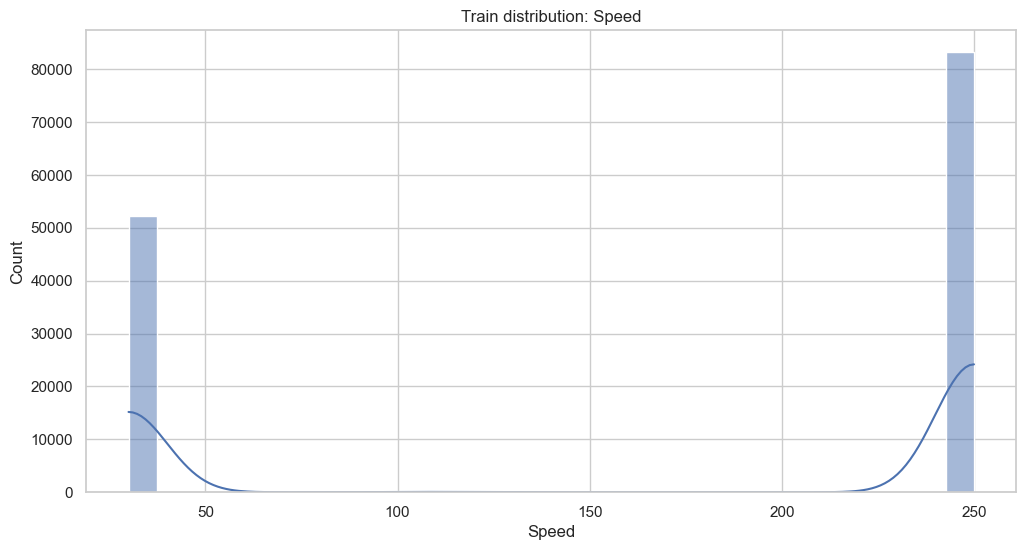

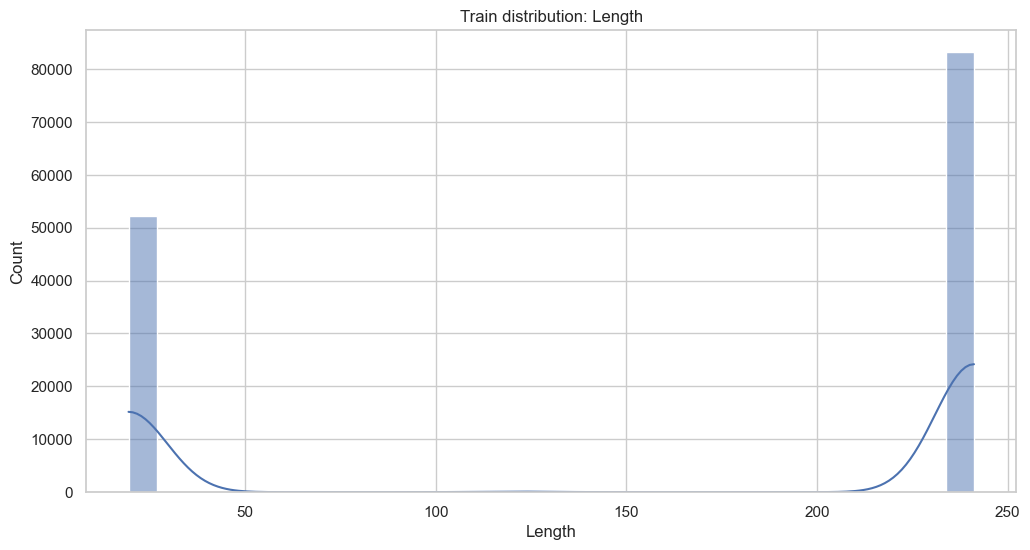

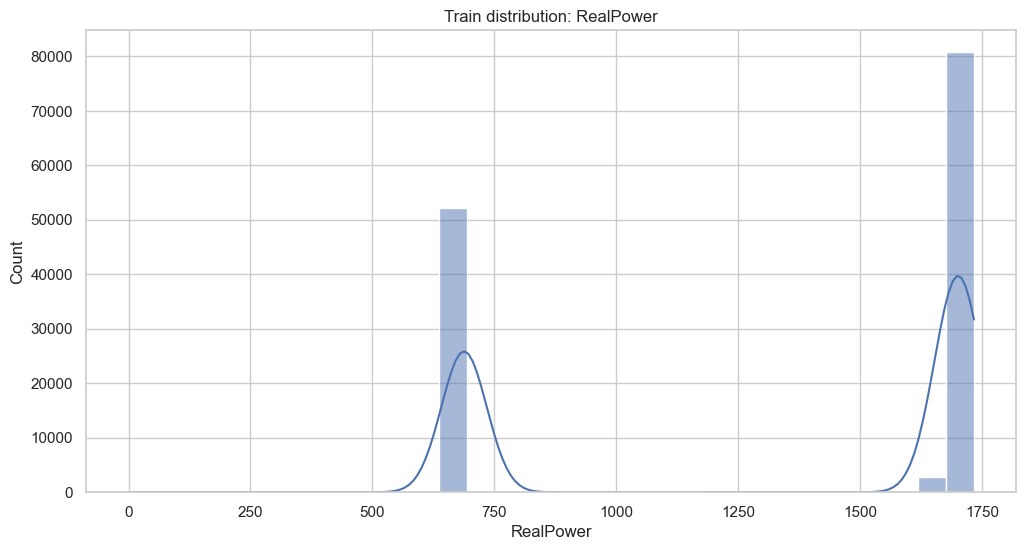

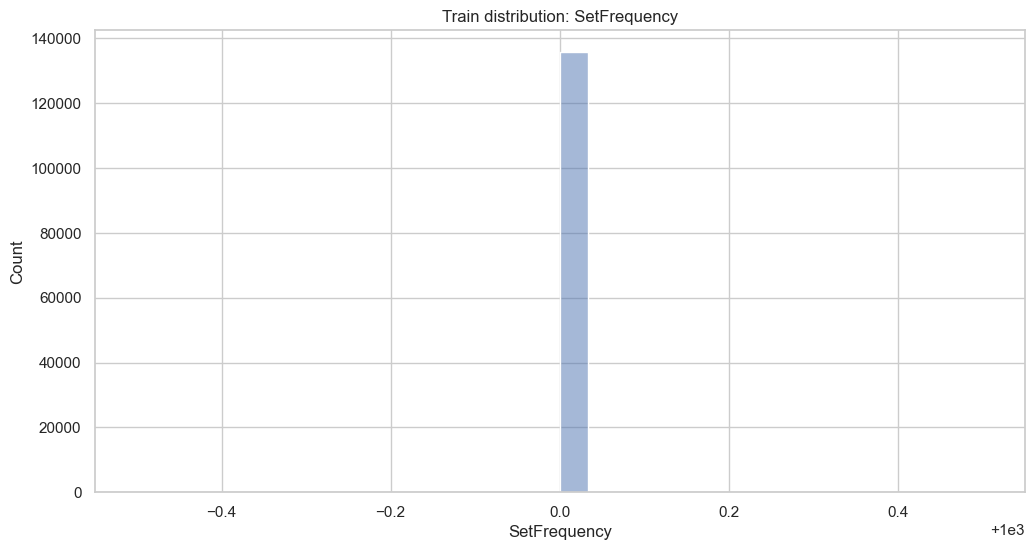

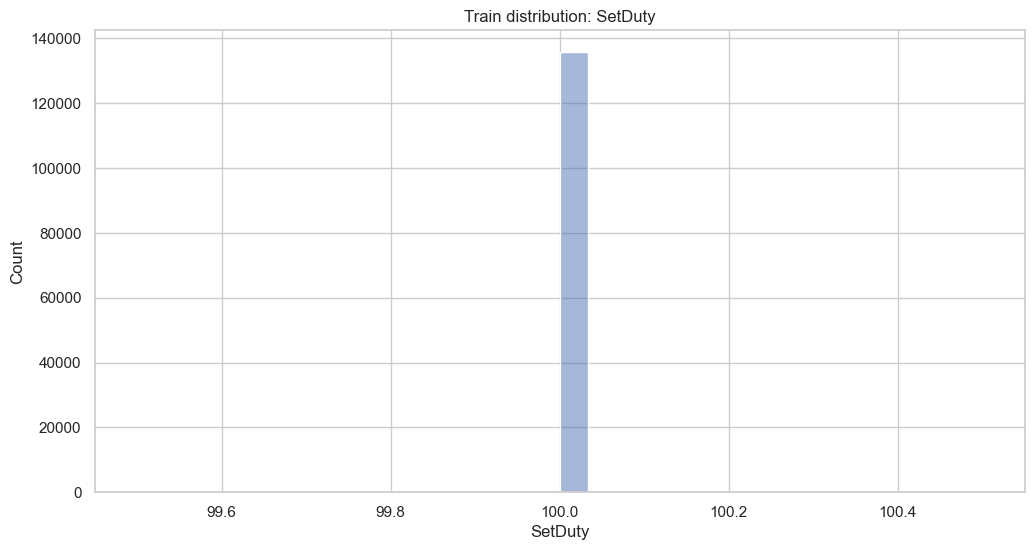

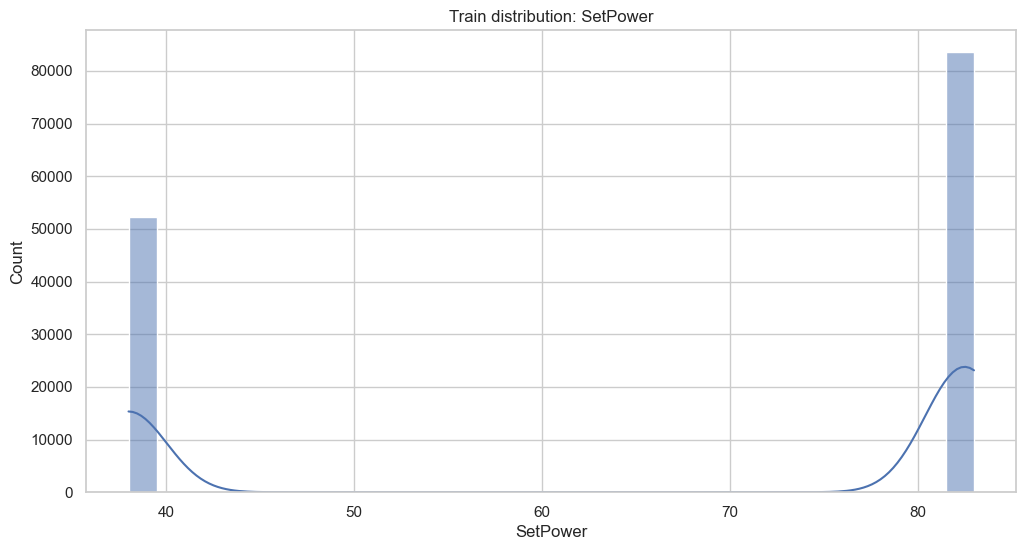

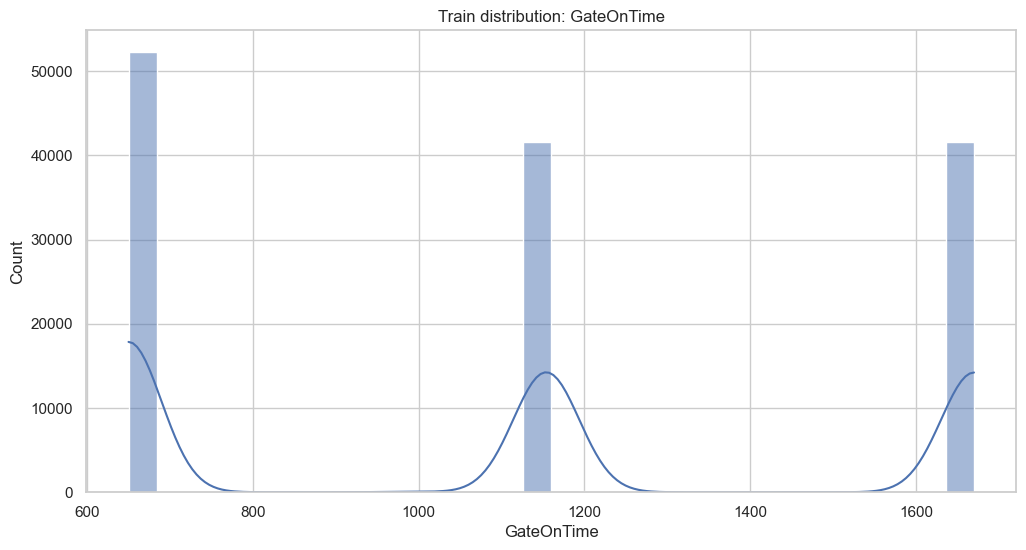

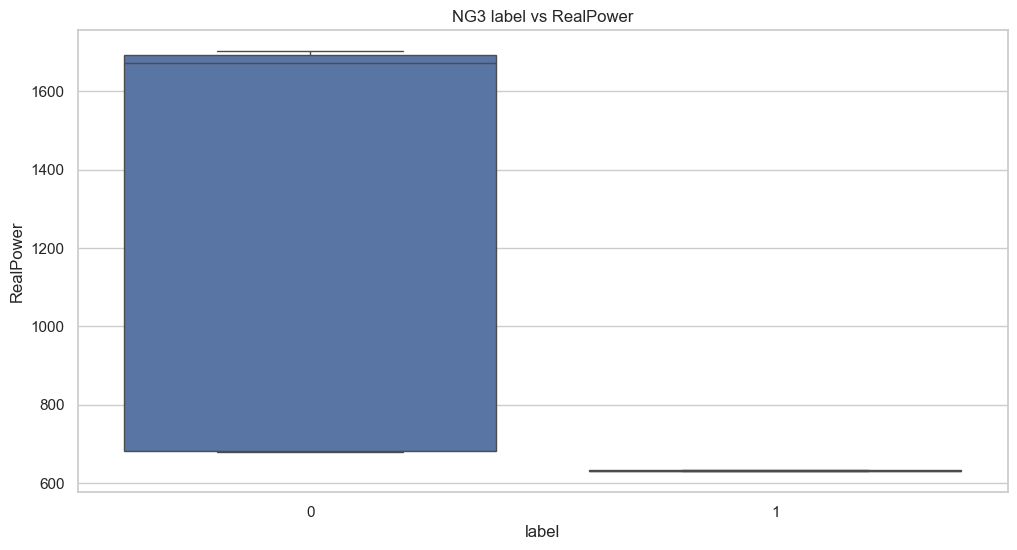

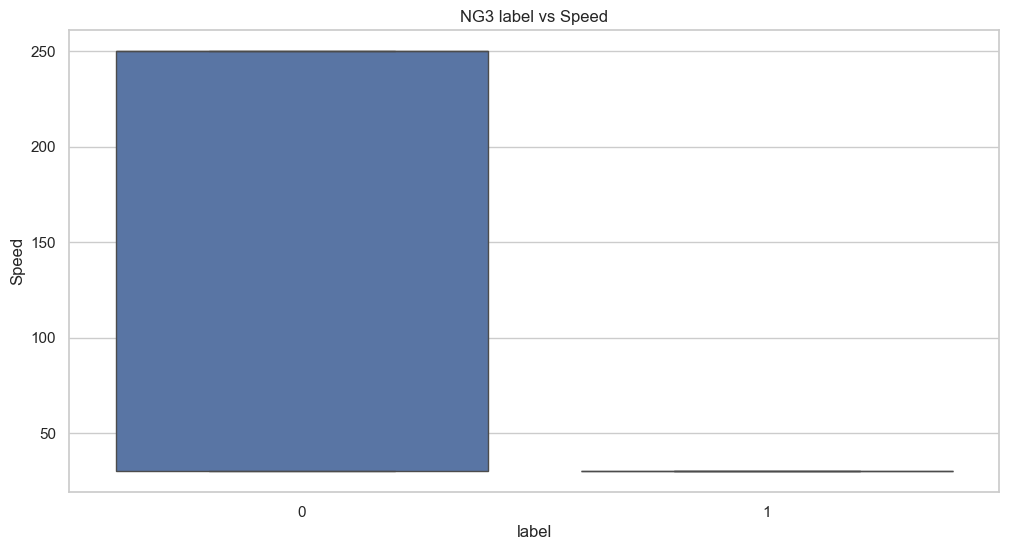

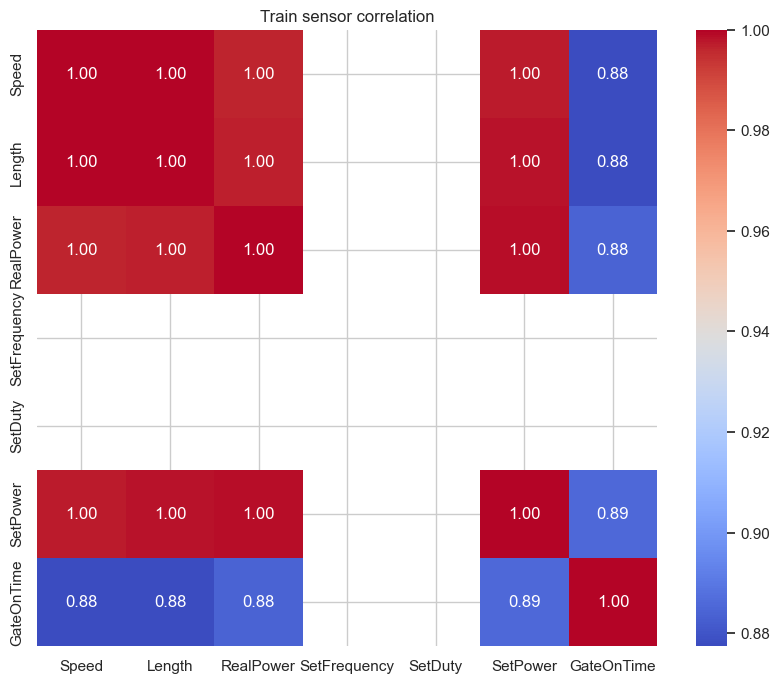

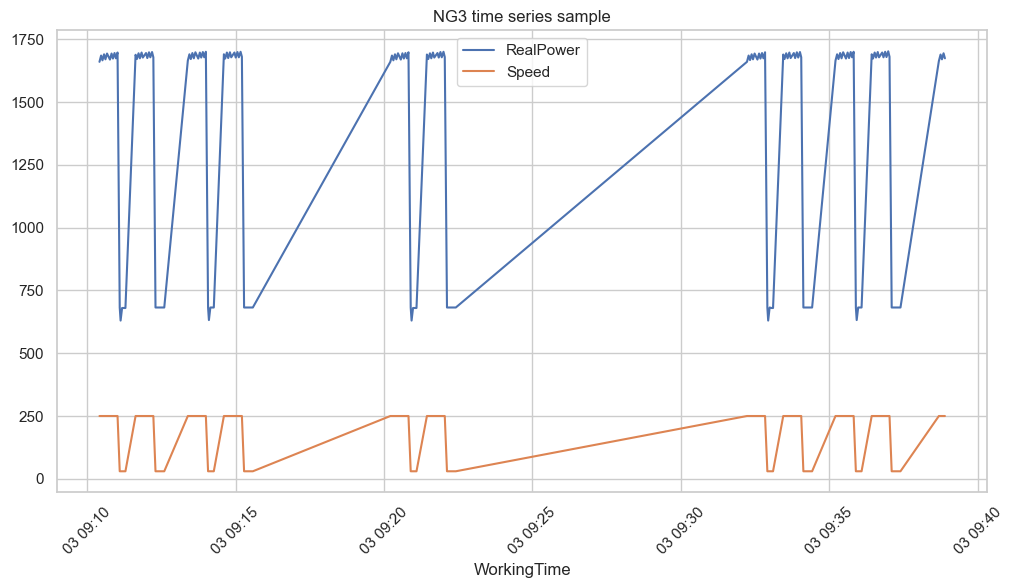

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams["figure.figsize"] = (12, 6)
sns.set(style="whitegrid")

base = Path(r"c:\Users\채재헌\OneDrive - 계명대학교\바탕 화면\Research")
raw = base / "data" / "raw_data"

train = pd.read_csv(raw / "train" / "Training_Data.csv", parse_dates=["WorkingTime"])
ng3 = pd.read_csv(raw / "test" / "WeldingTest_03_NG_labeled.csv", parse_dates=["WorkingTime"])
ng4 = pd.read_csv(raw / "test" / "WeldingTest_04_NG_labeled.csv", parse_dates=["WorkingTime"])

features = ["Speed", "Length", "RealPower", "SetFrequency", "SetDuty", "SetPower", "GateOnTime"]

# 1) 변수 분포
for col in features:
    plt.figure()
    sns.histplot(train[col], kde=True, bins=30)
    plt.title(f"Train distribution: {col}")
    plt.show()

# 2) 정상 vs NG 비교 (NG3)
plt.figure()
sns.boxplot(x="label", y="RealPower", data=ng3)
plt.title("NG3 label vs RealPower")
plt.show()

plt.figure()
sns.boxplot(x="label", y="Speed", data=ng3)
plt.title("NG3 label vs Speed")
plt.show()

# 3) 상관관계 히트맵
corr = train[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Train sensor correlation")
plt.show()

# 4) 시간 경과 추이 (NG3 예시)
sample = ng3.sort_values("WorkingTime").head(200)
plt.figure()
plt.plot(sample["WorkingTime"], sample["RealPower"], label="RealPower")
plt.plot(sample["WorkingTime"], sample["Speed"], label="Speed")
plt.legend()
plt.title("NG3 time series sample")
plt.xlabel("WorkingTime")
plt.xticks(rotation=45)
plt.show()